# 04 Your own configuration

- **Tier:** laptop (CPU only)
- **Run time:** about 6 min (measured: 346 s on a compute node pinned to 8 cores; five short runs, mostly
  compiling)
- **Peak memory:** about 5.5 GB (measured: 5.2 GiB)
- **Experiment:** copies of `verification/tutorial_barotropic_gyre` and `verification/1D_ocean_ice_column`
  outside the MITgcm tree, and a new idealised box written from scratch
- **Shows:** (a) a verification experiment copied and changed: run length, a namelist parameter, a forcing file, a
  new tiling in `SIZE.h`, and what a new build means for MAX/MIN; (b) a configuration from scratch with its own
  `code/` and `input/`; (c) what happens with an option or a routine mitjax has not ported, and how to read the
  error.

An experiment directory for mitjax is what it is for MITgcm: a `code/` directory (genmake2's `-mods`: `SIZE.h`,
CPP options, `packages.conf`) and an input directory (`data`, `data.pkg`, `eedata`, binary files). It can live
anywhere; only the MITgcm sources (`model/`, `pkg/`, `eesupp/`) come from `$MJX_UPSTREAM`.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import re
import shutil
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import mitjax
from mitjax import paths

VERIFICATION = paths.UPSTREAM / "verification"
HERE = Path.cwd()


def new_dir(name):
    """A new directory <name>-<n> next to this notebook (runs and experiments are never overwritten)."""
    n = 1
    while Path(f"{name}-{n}").exists():
        n += 1
    return Path(f"{name}-{n}")


def copy_experiment(name, dst, dirs=("code", "input", "results")):
    """Copy verification/<name>'s code, input and results directories to dst, following symbolic links."""
    for d in dirs:
        shutil.copytree(VERIFICATION / name / d, dst / d, symlinks=False)
    return dst


def run_and_report(exp, out):
    """exp.run(out=...), with the Python warnings it raises printed as one line each (category and message)."""
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        run = exp.run(out=out)
    caught = [w for w in caught if w.category.__module__.startswith("mitjax")]
    for w in caught:
        print(f"{w.category.__name__}: {w.message}")
    print(f"{len(caught)} mitjax warning(s)")
    return run, caught


def short(text):
    """An error message with this notebook's directory written as '.'."""
    return str(text).replace(str(HERE.resolve()), ".").replace(str(HERE), ".")


def set_size(exp_dir, **values):
    """Change PARAMETERs of <exp_dir>/code/SIZE.h, e.g. set_size(d, sNx=31, nSx=2)."""
    p = exp_dir / "code" / "SIZE.h"
    text = p.read_text()
    for name, v in values.items():
        text, n = re.subn(rf"(&\s+{name}\s*=)\s*\d+,", rf"\g<1>{v:4d},", text)
        assert n == 1, name
    p.write_text(text)


def set_namelist(path, name, value):
    """Set `name=value,` in a namelist file (the line must exist)."""
    text, n = re.subn(rf"^(\s*{name}\s*=).*$", rf"\g<1>{value},", path.read_text(), flags=re.M | re.I)
    assert n == 1, name
    path.write_text(text)

## (a) A verification experiment, copied and changed

Copy `tutorial_barotropic_gyre` out of the MITgcm tree. First only a new tiling: `SIZE.h` with 2 x 2 tiles of
31 x 31 points instead of one tile of 62 x 62. The physics is unchanged, so this run is compared with the
experiment's `results/` (written by the one-tile Fortran build).

In [2]:
gyre = copy_experiment("tutorial_barotropic_gyre", new_dir("my_experiments/gyre"))
set_size(gyre, sNx=31, sNy=31, nSx=2, nSy=2)
print(re.search(r"PARAMETER \((.*?)\)", (gyre / "code" / "SIZE.h").read_text(), re.S).group(1))
exp = mitjax.load(gyre)
run4, w4 = run_and_report(exp, new_dir("runs/04_gyre_2x2"))
rep = mitjax.compare(run4, exp.results())
print(rep.summary)
print("  ".join(f"{v.name} {v.digits}" for v in rep.run.variables))
assert rep.verdict == "pass" and rep.run.variables[0].digits >= 10    # testreport: the first variable decides
assert run4.fields["etaN"].shape[0] == 4           # four tiles


     &           sNx =  31,
     &           sNy =  31,
     &           OLx =   2,
     &           OLy =   2,
     &           nSx =   2,
     &           nSy =   2,
     &           nPx =   1,
     &           nPy =   1,
     &           Nx  = sNx*nSx*nPx,
     &           Ny  = sNy*nSy*nPy,
     &           Nr  =   1


0 mitjax warning(s)
Y Y Y Y>13<16 16 16 22 16 16 16 22 16 16  0 16 16 16  0 16  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  .  . pass  gyre-1
PS 13  Tmn 16  Tmx 16  Tav 16  Tsd 22  Smn 16  Smx 16  Sav 16  Ssd 22  Umn 16  Umx 16  Uav 0  Usd 16  Vmn 16  Vmx 16  Vav 0  Vsd 16


Not every digit is the same as the one-tile run's, and that is expected: with four tiles the global sums (in the
CG2D solver and in the monitor) add the tiles' partial sums, a different order of additions than one tile, as in
the Fortran. The first variable (`PS`, from `cg2d_init_res`, the one testreport decides on) kept 13 digits on our
machine. `Uav` and `Vav`, the domain means of `u` and `v`, show 0 digits because at the first steps those
means are round-off noise around zero, where any change of summation order changes every digit:

In [3]:
def monitor(path, name):
    return [ln.split("=")[1].strip() for ln in Path(path).read_text().splitlines() if f"%MON {name} " in ln]


ref_u = monitor(exp.results().output, "dynstat_uvel_mean")
new_u = monitor(run4.output, "dynstat_uvel_mean")
print("dynstat_uvel_mean   1 tile (Fortran)     2 x 2 tiles (mitjax)")
for k in range(4):
    print(f"record {k}          {ref_u[k]:>20s}  {new_u[k]:>20s}")

dynstat_uvel_mean   1 tile (Fortran)     2 x 2 tiles (mitjax)
record 0           0.0000000000000E+00   0.0000000000000E+00
record 1           1.0177461525141E-21   2.1551961952684E-21
record 2           7.2624744836893E-21   4.3103923905367E-21
record 3          -5.9119621489805E-09  -5.9119621489746E-09


A new `SIZE.h` is a new build for MITgcm, and for mitjax too: the exchange maps for the new tiles are computed
from the exchange code when the experiment is loaded, nothing has to be prepared. This build printed no warning;
the next cells show one that does.

Now the physics: twice the run length (`nTimeSteps`), a larger viscosity (`viscAh`), and a new wind-stress file:
a double-gyre wind, written as MITgcm reads it (big-endian `float32`, `readBinaryPrec = 32`, the default).

 viscAh=8.E2,
 nTimeSteps=20,
 zonalWindFile='windx_double.bin',


0 mitjax warning(s)


etaN (62, 62)  grid spacing dxF = 20000.0 m


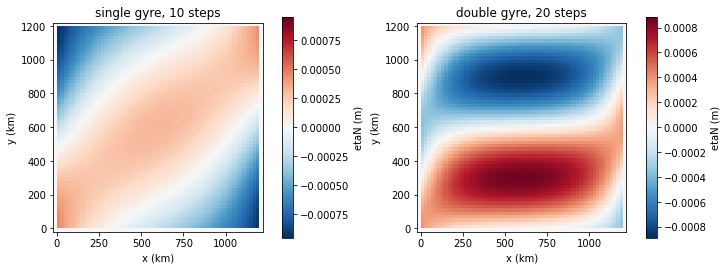

In [4]:
data = gyre / "input" / "data"
set_namelist(data, "nTimeSteps", 20)
set_namelist(data, "viscAh", "8.E2")
nx = ny = 62
y = (np.arange(ny) - 0.5) / (ny - 2)               # as gendata.py: y at the cell centres, 0..1 across the basin
tau = -0.1 * np.cos(2 * np.pi * y)[:, None] * np.ones((1, nx))
tau.astype(">f4").tofile(gyre / "input" / "windx_double.bin")
set_namelist(data, "zonalWindFile", "'windx_double.bin'")
print("\n".join(ln for ln in data.read_text().splitlines()
                if re.match(r"\s*(nTimeSteps|viscAh|zonalWindFile)", ln)))

exp2 = mitjax.load(gyre)
run_dg, _ = run_and_report(exp2, new_dir("runs/04_gyre_double"))
eta_a, eta_b = run4.global_field("etaN"), run_dg.global_field("etaN")    # [j, i]: the four tiles put together
grid = exp2.grid()                                 # GRID.h arrays by Fortran name, no run needed
x, y = grid.global_field("xC") / 1e3, grid.global_field("yC") / 1e3       # cell centres (km)
print("etaN", eta_b.shape, " grid spacing dxF =", grid.global_field("dxF")[0, 0], "m")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8), dpi=72, constrained_layout=True)
for a, e, t in ((ax[0], eta_a, "single gyre, 10 steps"), (ax[1], eta_b, "double gyre, 20 steps")):
    pc = a.pcolormesh(x, y, e, cmap="RdBu_r", vmin=-abs(e).max(), vmax=abs(e).max(), shading="nearest")
    fig.colorbar(pc, ax=a, label="etaN (m)")
    a.set_title(t); a.set_aspect("equal"); a.set_xlabel("x (km)"); a.set_ylabel("y (km)")
plt.show()
assert np.isfinite(eta_b).all() and np.abs(eta_b).max() > 0

### A new build where MAX/MIN depends on the build

At a few statements gfortran's choice between the two arguments of `MAX`/`MIN` (when they tie with different
signs of zero, or one is NaN) depends on the build; today these are two statements of `pkg/seaice/seaice_growth.F`
(lines 1847-1848, executed with `SEAICE_areaLossFormula = 3`). mitjax knows the answer where our Fortran
reference measured it: in its builds, identified by a hash of the preprocessed options, the package list and
`SIZE.h`, that execute the statement. Anywhere else (a new build, or one of ours whose namelist switches the
statement on) mitjax takes the documented default and says so with a `mitjax.MinMaxDefaultWarning`, once per
build and statement (plan decision 7).

The gyre above does not reach such a statement, so its new build printed nothing. Here one that does: a copy of
`1D_ocean_ice_column` (one ocean column with sea ice) with a new `SIZE.h` (overlaps of 3 instead of 2 points: the
only tiling change a 1 x 1 domain allows) and `SEAICE_areaLossFormula = 3` in `data.seaice`.

In [5]:
col = copy_experiment("1D_ocean_ice_column", new_dir("my_experiments/1D_ocean_ice_column"))
set_size(col, OLx=3, OLy=3)
seaice = col / "input" / "data.seaice"
seaice.write_text(seaice.read_text().replace(" &SEAICE_PARM01\n",
                                             " &SEAICE_PARM01\n      SEAICE_areaLossFormula = 3,\n", 1))
exp_col = mitjax.load(col)
from mitjax.ops import fortran_minmax
fortran_minmax._WARNED.clear()                     # only for running this cell again in the same kernel (see below)
run_col, w_col = run_and_report(exp_col, new_dir("runs/04_column"))
assert [w.category for w in w_col] == [mitjax.MinMaxDefaultWarning] * 2
assert all("seaice_growth.F:184" in str(w.message) for w in w_col)
heff = [ln for ln in run_col.output.read_text().splitlines() if "%MON seaice_heff_max" in ln]
print(heff[-1])

2 mitjax warning(s)
(PID.TID 0000.0001) %MON seaice_heff_max              =   8.2268632222598E-03


How to read the warning: it names the statement by its Fortran file and line, says which argument (`p`) is used
there, and that this build is not one our Fortran reference measured. It can differ from your own gfortran build
of the same `code/` only where the two arguments tie with opposite signs of zero or one of them is NaN; the run is
otherwise the same, just not guaranteed to be bit for bit equal to your Fortran build at that statement.
`warnings.simplefilter("ignore", mitjax.MinMaxDefaultWarning)` silences it.

mitjax warns once per build and statement in a Python process. A second copy with the same `code/` is the same
build (the identity is a hash of the contents, not of the directory), so running the cell above again would print
nothing. That is why the cell first empties mitjax's record of the warnings already given
(`fortran_minmax._WARNED`, a private name); a fresh kernel does not need it.
`docs/fortran_map.md` (the MAX/MIN convention) and `mitjax/config/build_identity.py` say more.

## (b) A configuration from scratch

A wind- and buoyancy-driven box: 24 x 20 points of 50 km on a beta plane, 5 levels, a linear equation of state
(temperature only), relaxation of the surface temperature to a north-south profile, implicit vertical diffusion and
convective mixing (`ivdc_kappa`). It is the physics of `tutorial_baroclinic_gyre` in a smaller box, written here
from nothing: `code/` with `SIZE.h` (4 tiles), `CPP_OPTIONS.h` (the model's default, copied to edit) and
`packages.conf`, and `input/` with `data`, `data.pkg`, `eedata` and three binary files. It uses only routines
mitjax has ported, which we found by running it (part (c) shows what an unported choice does).

In [6]:
SIZE_H = """C     SIZE.h of my_box: {nx} x {ny} points in {nt} tiles of {sNx} x {sNy}, {Nr} levels
      INTEGER sNx
      INTEGER sNy
      INTEGER OLx
      INTEGER OLy
      INTEGER nSx
      INTEGER nSy
      INTEGER nPx
      INTEGER nPy
      INTEGER Nx
      INTEGER Ny
      INTEGER Nr
      PARAMETER (
     &           sNx = {sNx:3d},
     &           sNy = {sNy:3d},
     &           OLx =   3,
     &           OLy =   3,
     &           nSx = {nSx:3d},
     &           nSy = {nSy:3d},
     &           nPx =   1,
     &           nPy =   1,
     &           Nx  = sNx*nSx*nPx,
     &           Ny  = sNy*nSy*nPy,
     &           Nr  = {Nr:3d})

      INTEGER MAX_OLX
      INTEGER MAX_OLY
      PARAMETER ( MAX_OLX = OLx,
     &            MAX_OLY = OLy )
"""

DATA = """ &PARM01
 viscAh=1.E4,
 viscAr=1.E-3,
 no_slip_sides=.TRUE.,
 no_slip_bottom=.FALSE.,
 diffKhT=1.E3,
 diffKrT=1.E-5,
 ivdc_kappa=1.,
 implicitDiffusion=.TRUE.,
 eosType='LINEAR',
 tRef={tRef},
 tAlpha=2.E-4,
 sBeta=0.,
 rhoNil=1000.,
 gravity=9.81,
 f0=1.E-4,
 beta=1.E-11,
 rigidLid=.FALSE.,
 implicitFreeSurface=.TRUE.,
 exactConserv=.TRUE.,
 saltStepping=.FALSE.,
 &
 &PARM02
 cg2dTargetResidual=1.E-9,
 cg2dMaxIters=500,
 &
 &PARM03
 nIter0=0,
 nTimeSteps={nTimeSteps},
 deltaT=1800.,
 pChkptFreq=0.,
 chkptFreq=0.,
 dumpFreq=0.,
 monitorFreq=21600.,
 monitorSelect=2,
 tauThetaClimRelax=2592000.,
 &
 &PARM04
 usingCartesianGrid=.TRUE.,
 delX={nx}*{dx},
 delY={ny}*{dx},
 delR={delR},
 &
 &PARM05
 bathyFile='bathy.bin',
 zonalWindFile='windx.bin',
 thetaClimFile='sst_relax.bin',
 &
"""


def make_box(root, nTimeSteps=72):
    nx, ny, Nr = 24, 20, 5
    sNx, sNy, nSx, nSy = 12, 10, 2, 2
    dx = 50.e3
    delR = [100., 200., 300., 400., 500.]
    tRef = [20., 15., 10., 6., 4.]
    code, inp = root / "code", root / "input"
    code.mkdir(parents=True)
    inp.mkdir(parents=True)
    (code / "SIZE.h").write_text(SIZE_H.format(nx=nx, ny=ny, nt=nSx*nSy, sNx=sNx, sNy=sNy, nSx=nSx, nSy=nSy, Nr=Nr))
    (code / "packages.conf").write_text("gfd\n")
    shutil.copy(paths.UPSTREAM / "model" / "inc" / "CPP_OPTIONS.h", code / "CPP_OPTIONS.h")
    h = -sum(delR) * np.ones((ny, nx))                 # flat bottom, walls all around
    h[:, [0, -1]] = 0.
    h[[0, -1], :] = 0.
    h.astype(">f4").tofile(inp / "bathy.bin")
    Y = np.broadcast_to(((np.arange(ny) + 0.5) * dx)[:, None], (ny, nx))   # y of the cell centres
    Ly = (ny - 2) * dx
    (-0.1 * np.cos(2 * np.pi * (Y - dx) / Ly)).astype(">f4").tofile(inp / "windx.bin")      # N/m^2
    (20. - 16. * (Y - dx) / Ly).astype(">f4").tofile(inp / "sst_relax.bin")                 # deg C
    (inp / "data").write_text(DATA.format(tRef=",".join(f"{t:.1f}" for t in tRef), nTimeSteps=nTimeSteps, nx=nx,
                                          ny=ny, dx=f"{dx:.1f}", delR=",".join(f"{d:.1f}" for d in delR)))
    (inp / "data.pkg").write_text(" &PACKAGES\n &\n")
    (inp / "eedata").write_text(" &EEPARMS\n nTx=1,\n nTy=1,\n &\n")
    return root


box = make_box(new_dir("my_experiments/my_box"))
for p in sorted(box.rglob("*")):
    if p.is_file():
        print(p.relative_to(box))

code/CPP_OPTIONS.h
code/SIZE.h
code/packages.conf
input/bathy.bin
input/data
input/data.pkg
input/eedata
input/sst_relax.bin
input/windx.bin


0 mitjax warning(s)
(PID.TID 0000.0001) %MON dynstat_theta_max            =   1.9973812580097E+01
(PID.TID 0000.0001) %MON ke_max                       =   3.5352003412603E-04


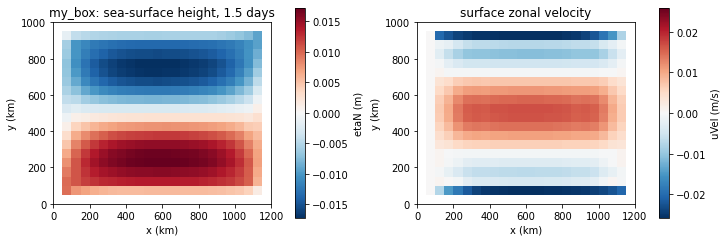

In [7]:
exp_box = mitjax.load(box)
run_box, w_box = run_and_report(exp_box, new_dir("runs/04_my_box"))
mon = [ln for ln in run_box.output.read_text().splitlines() if "%MON dynstat_theta_max" in ln
       or "%MON ke_max" in ln]
print("\n".join(mon[-2:]))


theta = run_box.global_field("theta")              # [k, j, i]
eta = run_box.global_field("etaN")
u = run_box.global_field("uVel")[0]
g_box = exp_box.grid()
x, y = g_box.global_field("xC") / 1e3, g_box.global_field("yC") / 1e3     # km
mask = g_box.global_field("maskC")[0] != 0         # wet at the surface
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4), dpi=72, constrained_layout=True)
pc = ax[0].pcolormesh(x, y, np.where(mask, eta, np.nan), cmap="RdBu_r", shading="nearest")
fig.colorbar(pc, ax=ax[0], label="etaN (m)")
ax[0].set_title("my_box: sea-surface height, 1.5 days")
pc = ax[1].pcolormesh(x, y, np.where(mask, u, np.nan), cmap="RdBu_r", vmin=-abs(u).max(), vmax=abs(u).max(),
                      shading="nearest")
fig.colorbar(pc, ax=ax[1], label="uVel (m/s)")
ax[1].set_title("surface zonal velocity")
for a in ax:
    a.set_aspect("equal"); a.set_xlabel("x (km)"); a.set_ylabel("y (km)")
plt.show()
assert w_box == [] and np.isfinite(theta).all() and np.isfinite(eta).all() and np.abs(u).max() > 0

## (c) When mitjax has not ported something

mitjax ports MITgcm's routines and options one by one; anything not ported stops the run with an error that names
the Fortran routine and the option or line, instead of computing something else. Three typical cases:

1. **Your own `.F` file in `code/`.** genmake2 would compile it in place of the model's routine. mitjax has no
   Fortran compiler: a `.F` in `code/` must be a routine mitjax has a Python port of (or an unchanged copy of the
   MITgcm file), otherwise loading stops (plan decision 11). Here a copy of `model/src/ini_vel.F` with one line
   changed:

In [8]:
own = copy_experiment("tutorial_barotropic_gyre", new_dir("my_experiments/gyre_own_ini_vel"))
src = (paths.UPSTREAM / "model" / "src" / "ini_vel.F").read_text()
(own / "code" / "ini_vel.F").write_text(src.replace("C     !DESCRIPTION:", "C     my change\nC     !DESCRIPTION:", 1))
try:
    mitjax.load(own)
    raise AssertionError("an unported own routine must be refused")
except Exception as e:
    err = e
print(f"{type(err).__name__}: {short(err)}")
assert type(err).__name__ == "UnportedRoutine" and "INI_VEL" in str(err)

UnportedRoutine: ./my_experiments/gyre_own_ini_vel-1/code: own source files without a Python port (decision 11): ini_vel.F (routine INI_VEL). Each must equal a ported version (mitjax/config/own_code.py PORTED) or the MITgcm file it replaces.


The error names the file, the routine (`INI_VEL`) and the rule. To use such a routine, port it: write the
Python version next to the others (`mitjax/verification/<experiment>/<code dir>/`) and register it in
`mitjax/config/own_code.py` (`PORTED`); `docs/configurations.md` will describe the steps.

2. **A misspelled or misplaced namelist variable.** The Fortran `READ` of a namelist stops on a variable the
   group does not have; so does mitjax, with the file and line. `pCellMix_select` belongs to `PARM04`, not
   `PARM01`:

In [9]:
opt = copy_experiment("tutorial_barotropic_gyre", new_dir("my_experiments/gyre_pcell"))
data = opt / "input" / "data"
data.write_text(data.read_text().replace(" viscAh=4.E2,", " viscAh=4.E2,\n pCellMix_select=1,"))
try:
    mitjax.load(opt)
    raise AssertionError("a variable outside its namelist group must be refused")
except Exception as e:
    err = e
print(f"{type(err).__name__}: {short(err)}")
assert "pCellMix_select" in str(err) and "PARM01" in str(err)

UnknownNamelistVariable: './my_experiments/gyre_pcell-1/input/data:5: pCellMix_select is not in NAMELIST /PARM01/ of ini_parms.F (the Fortran READ stops on it)'


3. **An option that is not ported.** In its right group, `pCellMix_select = 1` asks `CALC_VISCOSITY` for a branch
   mitjax does not have. The configuration loads; the error comes when the time step is traced, from the routine
   itself, with the Fortran lines of the missing branch:

In [10]:
data.write_text(data.read_text().replace(" pCellMix_select=1,\n", "").replace(
    " usingCartesianGrid=.TRUE.,", " usingCartesianGrid=.TRUE.,\n pCellMix_select=1,"))
exp_opt = mitjax.load(opt)
try:
    exp_opt.run(out=new_dir("runs/04_gyre_pcell"))
    raise AssertionError("an unported option must stop the run")
except NotImplementedError as e:
    err = e
print(f"{type(err).__name__}: {short(err)}")
assert "CALC_VISCOSITY" in str(err) and "pCellMix_select" in str(err)

NotImplementedError: CALC_VISCOSITY: pCellMix_select > 0 (:170-394) is not ported


How to read it: `CALC_VISCOSITY` is the routine (`model/src/calc_viscosity.F`), `(:170-394)` the lines of that
file the branch occupies, `pCellMix_select > 0` the condition. `docs/fortran_map.md` lists what each routine's
port covers; the not-ported branches are listed in the docstring of the Python routine.